# Channel Ceiling Analysis

## Goal
Characterize what each scoring channel actually contributes before fitting models.

Three channels, three questions:
- **MS2** (entropy similarity): where does it saturate? At what similarity does it stop being informative?
- **RT** (delta_rt): can it discriminate where MS2 fails — specifically for structural isomers?
- **MS1** (delta_ppm): what's its role? (Structural isomers have identical mass — MS1 contributes nothing there, but narrows candidates for non-isomers.)

Proxy isomer set: 116 confirmed spectra where the best wrong candidate scores sim > 0.9.
These are the cases where MS2 is effectively blind. Does RT rescue them?

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm, gaussian_kde
from scipy.stats import t as sp_t
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT    = '/Users/ellayoung/Desktop/metabolo_confi_score'
DATA    = f'{ROOT}/data'
OUT     = f'{ROOT}/results/current'

assertions = pd.read_csv(f'{OUT}/assertions.csv')
hits_raw   = pd.read_csv(f'{DATA}/hilic_ttof_neg_masswiki_hits_new.csv')

# Exclude yy_ tentative annotations — filter by query spectrum name
spectra   = pd.read_csv(f'{DATA}/ttof+neg+hilic.csv', low_memory=False)
yy_wids   = set(spectra[spectra['name'].str.startswith('yy', na=False)]['wiki_id'])

all_confirmed = assertions[assertions['confirmed']].copy()
confirmed     = all_confirmed[~all_confirmed['wiki_id'].isin(yy_wids)].copy()

n_excluded = all_confirmed['wiki_id'].nunique() - confirmed['wiki_id'].nunique()
print(f'Confirmed spectra (total): {all_confirmed["wiki_id"].nunique()}')
print(f'  clean (non-yy_):         {confirmed["wiki_id"].nunique()}')
print(f'  excluded yy_:            {n_excluded}')

tp = confirmed[confirmed['correct']].copy()
fp = confirmed[~confirmed['correct']].copy()

print('Confirmed hits — TP: %d  FP: %d' % (len(tp), len(fp)))
print('Confirmed spectra:', confirmed['wiki_id'].nunique())

## Step 1 — MS2 Information Ceiling

### 1a. TP vs FP similarity distributions — where do they overlap?

The LR = p(sim | TP) / p(sim | FP). Where these distributions overlap, LR ≈ 1 — MS2 provides no information.

### 1b. Isomer proxy set: 116 spectra where runner-up scores sim > 0.9

For each of these spectra:
- Correct candidate sim (TP best)
- Runner-up FP sim (best wrong)
- Gap = TP sim − FP sim  →  if gap ≈ 0, MS2 is blind

### 1c. Molecular formula check via SMILES

For spectra where both correct and runner-up have SMILES, compute molecular formula.
If formulas match → confirmed structural isomers. If not → coincidental spectral overlap.

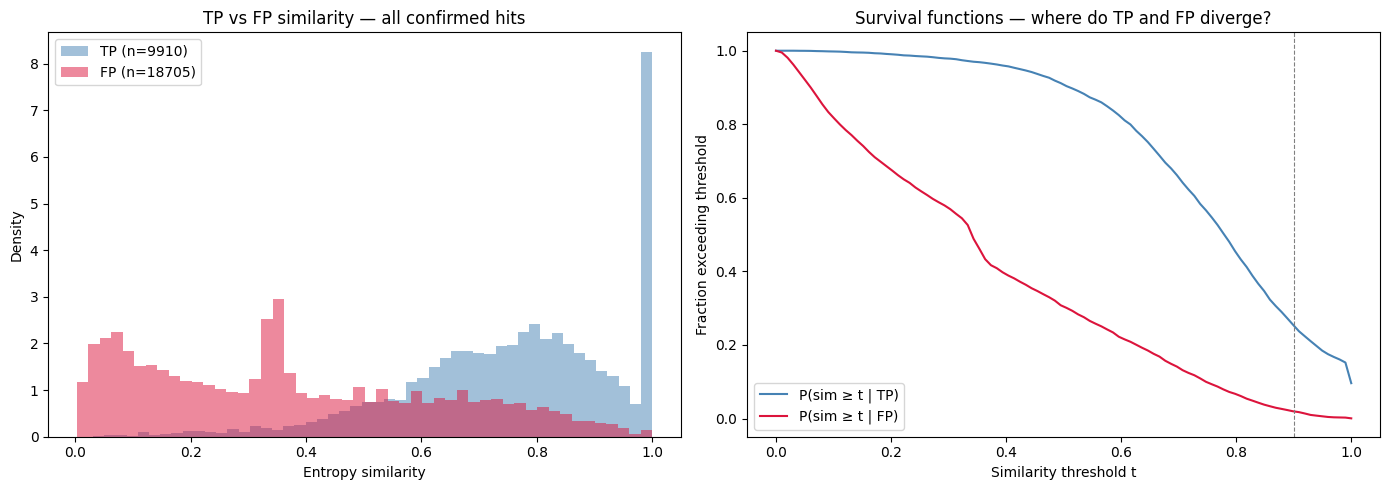

Fraction of TP with sim > 0.9: 25.3%
Fraction of FP with sim > 0.9: 1.9%
LR at sim > 0.9 (survival ratio): 13.1

Fraction of TP with sim > 0.7: 65.6%
Fraction of FP with sim > 0.7: 13.8%
LR at sim > 0.7 (survival ratio): 4.7


In [16]:
# ── 1a. Overall similarity distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sim_grid = np.linspace(0, 1, 500)

ax = axes[0]
tp_sim = tp['entropy_similarity'].dropna().values
fp_sim = fp['entropy_similarity'].dropna().values
ax.hist(tp_sim, bins=50, density=True, alpha=0.5, color='steelblue', label='TP (n=%d)' % len(tp_sim))
ax.hist(fp_sim, bins=50, density=True, alpha=0.5, color='crimson',   label='FP (n=%d)' % len(fp_sim))
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('Density')
ax.set_title('TP vs FP similarity — all confirmed hits')
ax.legend()

# Where do they overlap? Compute overlap integral as function of threshold
ax2 = axes[1]
thresholds = np.linspace(0, 1, 100)
tp_frac = [(tp_sim >= t).mean() for t in thresholds]
fp_frac = [(fp_sim >= t).mean() for t in thresholds]
lr_proxy = [tp / (fp + 1e-6) for tp, fp in zip(tp_frac, fp_frac)]

ax2.plot(thresholds, tp_frac, color='steelblue', label='P(sim ≥ t | TP)')
ax2.plot(thresholds, fp_frac, color='crimson',   label='P(sim ≥ t | FP)')
ax2.set_xlabel('Similarity threshold t')
ax2.set_ylabel('Fraction exceeding threshold')
ax2.set_title('Survival functions — where do TP and FP diverge?')
ax2.legend()
ax2.axvline(0.9, color='gray', linestyle='--', lw=0.8, label='sim=0.9')

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/channel_ms2_distributions.png', dpi=150)
plt.show()

print('Fraction of TP with sim > 0.9: %.1f%%' % ((tp_sim > 0.9).mean() * 100))
print('Fraction of FP with sim > 0.9: %.1f%%' % ((fp_sim > 0.9).mean() * 100))
print('LR at sim > 0.9 (survival ratio): %.1f' % ((tp_sim > 0.9).mean() / ((fp_sim > 0.9).mean() + 1e-6)))
print()
print('Fraction of TP with sim > 0.7: %.1f%%' % ((tp_sim > 0.7).mean() * 100))
print('Fraction of FP with sim > 0.7: %.1f%%' % ((fp_sim > 0.7).mean() * 100))
print('LR at sim > 0.7 (survival ratio): %.1f' % ((tp_sim > 0.7).mean() / ((fp_sim > 0.7).mean() + 1e-6)))


Isomer proxy cases (runner-up sim > 0.9): 105

MS2 gaps in isomer cases:
count    105.000000
mean       0.048262
std        0.052251
min       -0.379918
25%        0.027722
50%        0.057379
75%        0.077146
max        0.099999
Name: sim_gap, dtype: float64

Isomer cases with RT for both: 105 / 105
Abs RT difference — correct: 8.902163353209303   runner-up: 11.40682518156548


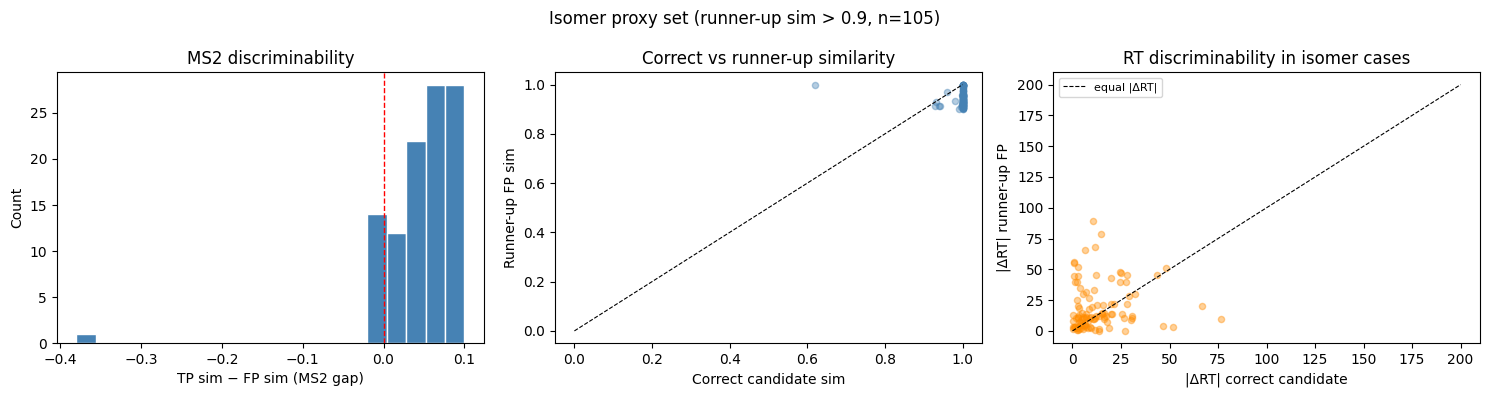

In [17]:
# ── 1b. Isomer proxy set: 116 spectra where runner-up sim > 0.9 ───────────
# For each confirmed spectrum, get best TP and best FP hit
tp_best = (tp.sort_values('entropy_similarity', ascending=False)
             .groupby('wiki_id').first()
             .reset_index()
             [['wiki_id','entropy_similarity','delta_rt','delta_ppm','lib_name']]
             .rename(columns={'entropy_similarity':'tp_sim',
                              'delta_rt':'tp_drt',
                              'delta_ppm':'tp_dppm',
                              'lib_name':'tp_lib'}))

fp_best = (fp.sort_values('entropy_similarity', ascending=False)
             .groupby('wiki_id').first()
             .reset_index()
             [['wiki_id','entropy_similarity','delta_rt','delta_ppm','lib_name']]
             .rename(columns={'entropy_similarity':'fp_sim',
                              'delta_rt':'fp_drt',
                              'delta_ppm':'fp_dppm',
                              'lib_name':'fp_lib'}))

pairs = tp_best.merge(fp_best, on='wiki_id')
pairs['sim_gap'] = pairs['tp_sim'] - pairs['fp_sim']

# Isomer proxy: runner-up sim > 0.9
isomers = pairs[pairs['fp_sim'] > 0.9].copy()
print('Isomer proxy cases (runner-up sim > 0.9): %d' % len(isomers))
print()
print('MS2 gaps in isomer cases:')
print(isomers['sim_gap'].describe())
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Isomer proxy set (runner-up sim > 0.9, n=%d)' % len(isomers))

axes[0].hist(isomers['sim_gap'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=1)
axes[0].set_xlabel('TP sim − FP sim (MS2 gap)')
axes[0].set_title('MS2 discriminability')
axes[0].set_ylabel('Count')

axes[1].scatter(isomers['tp_sim'], isomers['fp_sim'], alpha=0.4, s=20, color='steelblue')
axes[1].plot([0,1],[0,1],'k--', lw=0.8)
axes[1].set_xlabel('Correct candidate sim')
axes[1].set_ylabel('Runner-up FP sim')
axes[1].set_title('Correct vs runner-up similarity')

# RT gap for isomer cases (where RT is available)
iso_rt = isomers.dropna(subset=['tp_drt','fp_drt']).copy()
iso_rt['rt_gap_abs'] = np.abs(iso_rt['tp_drt']) - np.abs(iso_rt['fp_drt'])
print('Isomer cases with RT for both: %d / %d' % (len(iso_rt), len(isomers)))
print('Abs RT difference — correct:', iso_rt['tp_drt'].abs().median(),
      '  runner-up:', iso_rt['fp_drt'].abs().median())

axes[2].scatter(iso_rt['tp_drt'].abs(), iso_rt['fp_drt'].abs(),
                alpha=0.4, s=20, color='darkorange')
axes[2].plot([0,200],[0,200],'k--', lw=0.8, label='equal |ΔRT|')
axes[2].set_xlabel('|ΔRT| correct candidate')
axes[2].set_ylabel('|ΔRT| runner-up FP')
axes[2].set_title('RT discriminability in isomer cases')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/channel_isomer_ceiling.png', dpi=150)
plt.show()


In [18]:
# ── 1c. Molecular formula check on isomer proxies ─────────────────────────
def smiles_to_formula(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return rdMolDescriptors.CalcMolFormula(mol)

# Attach SMILES from hits_raw
smiles_map = hits_raw.set_index('lib_name')['smiles'].to_dict()

isomers['tp_smiles'] = isomers['tp_lib'].map(smiles_map)
isomers['fp_smiles'] = isomers['fp_lib'].map(smiles_map)
isomers['tp_formula'] = isomers['tp_smiles'].apply(smiles_to_formula)
isomers['fp_formula'] = isomers['fp_smiles'].apply(smiles_map.get if False else smiles_to_formula)
isomers['fp_formula'] = isomers['fp_smiles'].apply(smiles_to_formula)

has_both = isomers.dropna(subset=['tp_formula','fp_formula'])
same_formula = has_both[has_both['tp_formula'] == has_both['fp_formula']]
diff_formula = has_both[has_both['tp_formula'] != has_both['fp_formula']]

print('Isomer proxy cases with SMILES for both: %d / %d' % (len(has_both), len(isomers)))
print()
print('Same molecular formula (true structural isomers): %d (%.0f%%)' % (
    len(same_formula), len(same_formula)/len(has_both)*100 if len(has_both) > 0 else 0))
print('Different formula (coincidental spectral overlap): %d (%.0f%%)' % (
    len(diff_formula), len(diff_formula)/len(has_both)*100 if len(has_both) > 0 else 0))

if len(same_formula) > 0:
    print()
    print('True structural isomer cases — MS2 gap:')
    print(same_formula['sim_gap'].describe())
    print()
    print('Sample isomer pairs:')
    for _, r in same_formula.head(5).iterrows():
        print('  wid=%s  formula=%s  tp_sim=%.3f  fp_sim=%.3f  gap=%.3f' % (
            r['wiki_id'], r['tp_formula'], r['tp_sim'], r['fp_sim'], r['sim_gap']))


Isomer proxy cases with SMILES for both: 97 / 105

Same molecular formula (true structural isomers): 54 (56%)
Different formula (coincidental spectral overlap): 43 (44%)

True structural isomer cases — MS2 gap:
count    54.000000
mean      0.040437
std       0.067026
min      -0.379918
25%       0.014134
50%       0.047265
75%       0.077080
max       0.097490
Name: sim_gap, dtype: float64

Sample isomer pairs:
  wid=a6ICAHB/1018  formula=C7H6O6S  tp_sim=1.000  fp_sim=0.953  gap=0.047
  wid=a6ICAHB/1310  formula=C24H40O8S  tp_sim=1.000  fp_sim=1.000  gap=0.000
  wid=a6ICAHB/1731  formula=C8H16NO9P  tp_sim=1.000  fp_sim=0.977  gap=0.023
  wid=a6ICAHB/1759  formula=C2H6O4S  tp_sim=1.000  fp_sim=0.923  gap=0.077
  wid=a6ICAHB/1771  formula=C10H8O3S  tp_sim=1.000  fp_sim=0.915  gap=0.085


## Step 2 — RT Channel Characterization

RT is the key rescue channel. For confirmed TPs, |ΔRT| should be small (instrument is well-calibrated for known compounds). For FPs, ΔRT should be larger on average — they're matched by MS2 but the RT is wrong.

Critically: for structural isomers, two compounds with the same formula can have **very different RT** in HILIC (which separates by polarity and H-bonding). RPLC separates differently but also resolves many isomers. The RT channel has discriminative power exactly where MS2 saturates.

**Key question**: in the 116 isomer proxy cases, is |ΔRT(correct)| < |ΔRT(runner-up)|? If yes, RT is rescuing these cases.

In [19]:
print('All confirmed hits — RT stats:')
tp_drt = tp['delta_rt'].dropna()
fp_drt = fp['delta_rt'].dropna()
print('  TP |ΔRT|: median=%.1f  mean=%.1f  >30s: %.1f%%' % (
    np.median(np.abs(tp_drt)), np.abs(tp_drt).mean(), (np.abs(tp_drt) > 30).mean()*100))
print('  FP |ΔRT|: median=%.1f  mean=%.1f  >30s: %.1f%%' % (
    np.median(np.abs(fp_drt)), np.abs(fp_drt).mean(), (np.abs(fp_drt) > 30).mean()*100))

All confirmed hits — RT stats:
  TP |ΔRT|: median=9.6  mean=14.8  >30s: 11.8%
  FP |ΔRT|: median=16.0  mean=26.8  >30s: 32.1%


## Step 3 — MS2 Piecewise LR with Data-Driven Ceiling

Rather than an arbitrary cap, fit TP and FP Beta distributions in the 0.3–0.8 range
(where annotation bias is minimal and both classes are well-represented), then
extrapolate parametrically to 1.0.

In the 0.8–1.0 range, the LR naturally flattens because:
- TP density continues to rise (annotation bias pushes TP toward 1.0)
- But FP density also rises (isomers live here too)
- The Beta extrapolation captures this convergence more honestly than KDE

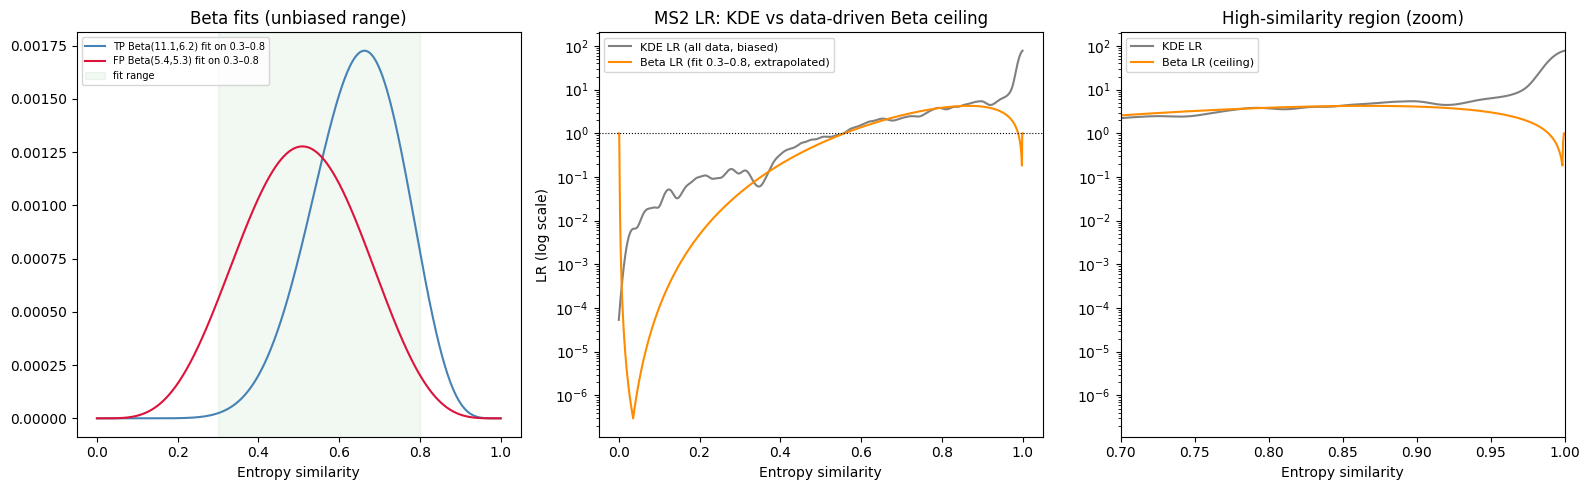

Beta fit — TP: a=11.14  b=6.16
Beta fit — FP: a=5.44  b=5.28

sim=0.50  KDE LR=   0.8  Beta LR=   0.6
sim=0.70  KDE LR=   2.2  Beta LR=   2.6
sim=0.80  KDE LR=   3.7  Beta LR=   3.9
sim=0.90  KDE LR=   5.4  Beta LR=   4.1
sim=0.95  KDE LR=   6.3  Beta LR=   3.0
sim=1.00  KDE LR=  78.0  Beta LR=   1.0


In [20]:
from scipy.stats import beta as sp_beta

sim_grid = np.linspace(0.0, 1.0, 2000)

def fit_beta_range(scores, lo=0.3, hi=0.8):
    """Fit Beta on scores within [lo, hi] only — avoids annotation-biased spike near 1."""
    s = scores[(scores >= lo) & (scores <= hi)]
    s = np.clip(s, 1e-4, 1 - 1e-4)
    a, b, _, _ = sp_beta.fit(s, floc=0, fscale=1)
    return a, b

# Fit on unbiased range 0.3–0.8
a_tp, b_tp = fit_beta_range(tp_sim, 0.3, 0.8)
a_fp, b_fp = fit_beta_range(fp_sim, 0.3, 0.8)

tp_beta = np.clip(sp_beta.pdf(sim_grid, a_tp, b_tp), 1e-10, None)
fp_beta = np.clip(sp_beta.pdf(sim_grid, a_fp, b_fp), 1e-10, None)
lr_beta = tp_beta / fp_beta

# Also compute KDE-based LR for comparison
from scipy.stats import gaussian_kde
tp_kde_g = np.clip(gaussian_kde(np.clip(tp_sim, 1e-4, 1-1e-4), bw_method=0.05)(sim_grid), 1e-10, None)
fp_kde_g = np.clip(gaussian_kde(np.clip(fp_sim, 1e-4, 1-1e-4), bw_method=0.05)(sim_grid), 1e-10, None)
lr_kde   = tp_kde_g / fp_kde_g

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(sim_grid, tp_beta / tp_beta.sum(), color='steelblue',
        label='TP Beta(%.1f,%.1f) fit on 0.3–0.8' % (a_tp, b_tp))
ax.plot(sim_grid, fp_beta / fp_beta.sum(), color='crimson',
        label='FP Beta(%.1f,%.1f) fit on 0.3–0.8' % (a_fp, b_fp))
ax.axvspan(0.3, 0.8, alpha=0.05, color='green', label='fit range')
ax.set_xlabel('Entropy similarity'); ax.set_title('Beta fits (unbiased range)')
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(sim_grid, lr_kde,  color='gray',       label='KDE LR (all data, biased)')
ax.plot(sim_grid, lr_beta, color='darkorange', label='Beta LR (fit 0.3–0.8, extrapolated)')
ax.axhline(1.0, color='black', linestyle=':', lw=0.8)
ax.set_yscale('log')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('LR (log scale)')
ax.set_title('MS2 LR: KDE vs data-driven Beta ceiling')
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(sim_grid, lr_kde,  color='gray',       label='KDE LR')
ax.plot(sim_grid, lr_beta, color='darkorange', label='Beta LR (ceiling)')
ax.set_xlim(0.7, 1.0)
ax.set_yscale('log')
ax.set_xlabel('Entropy similarity')
ax.set_title('High-similarity region (zoom)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/channel_ms2_ceiling.png', dpi=150)
plt.show()

print('Beta fit — TP: a=%.2f  b=%.2f' % (a_tp, b_tp))
print('Beta fit — FP: a=%.2f  b=%.2f' % (a_fp, b_fp))
print()
for s in [0.5, 0.7, 0.8, 0.9, 0.95, 1.0]:
    kde_lr  = np.interp(s, sim_grid, lr_kde)
    beta_lr = np.interp(s, sim_grid, lr_beta)
    print('sim=%.2f  KDE LR=%6.1f  Beta LR=%6.1f' % (s, kde_lr, beta_lr))


## Step 4 — Reliability Diagram Stratified by Dominant Channel

Using the existing 3-channel posteriors from `assertions.csv`.

For each confirmed hit, classify which channel dominates:
- **MS2-dominated**: LR_ms2 >> LR_ms1 (entropy similarity is doing the heavy lifting)
- **MS1-dominated**: LR_ms1 >> LR_ms2 (mass accuracy matters more — typically low-sim hits)
- **Balanced**: both channels contribute similarly

The claim: MS2-dominated hits at high similarity will show overconfidence (annotation bias lives here). MS1-dominated hits at lower similarity will show better calibration (annotation bias is weaker there).

Channel dominance:
dominant
MS1         13788
balanced    11753
MS2          3074
Name: count, dtype: int64


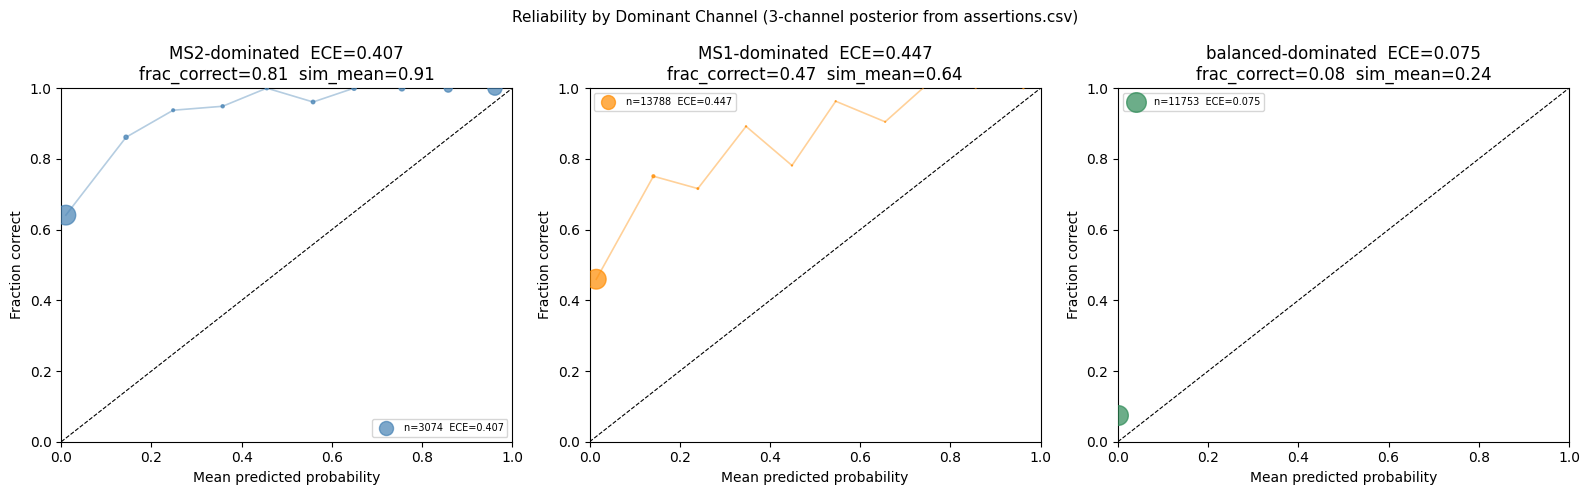

In [21]:
def reliability_diagram(ax, posteriors, labels, n_bins=10, color='steelblue', label=''):
    bins = np.linspace(0, 1, n_bins + 1)
    mean_p, frac_c, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (posteriors >= lo) & (posteriors < hi)
        if mask.sum() < 5:
            continue
        mean_p.append(posteriors[mask].mean())
        frac_c.append(labels[mask].mean())
        counts.append(mask.sum())
    if not mean_p:
        return np.nan
    mean_p = np.array(mean_p); frac_c = np.array(frac_c); counts = np.array(counts)
    ece = (counts / counts.sum() * np.abs(mean_p - frac_c)).sum()
    ax.plot([0,1],[0,1],'k--', lw=0.8)
    ax.scatter(mean_p, frac_c, s=counts/counts.max()*200, color=color, alpha=0.7, zorder=3,
               label='%s  ECE=%.3f' % (label, ece))
    ax.plot(mean_p, frac_c, color=color, alpha=0.4, lw=1.2)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction correct')
    ax.legend(fontsize=7)
    return ece

# Classify each hit by dominant channel
# log_lr_ms2 = log(LR_ms2), log_lr_ms1 = log(LR_ms1)
confirmed['log_lr_ms2'] = np.log(confirmed['LR_ms2'].clip(1e-6))
confirmed['log_lr_ms1'] = np.log(confirmed['LR_ms1'].clip(1e-6))
confirmed['label'] = confirmed['correct'].astype(int)

# Dominant channel: whichever log LR is larger in absolute value above 0
# MS2-dominated: |log_lr_ms2| > |log_lr_ms1| AND LR_ms2 > 1
ms2_dom = (confirmed['log_lr_ms2'].abs() > confirmed['log_lr_ms1'].abs()) & (confirmed['LR_ms2'] > 1)
ms1_dom = (confirmed['log_lr_ms1'].abs() > confirmed['log_lr_ms2'].abs()) & (confirmed['LR_ms1'] > 1)

confirmed['dominant'] = 'balanced'
confirmed.loc[ms2_dom, 'dominant'] = 'MS2'
confirmed.loc[ms1_dom, 'dominant'] = 'MS1'

print('Channel dominance:')
print(confirmed['dominant'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Reliability by Dominant Channel (3-channel posterior from assertions.csv)', fontsize=11)

colors = {'MS2': 'steelblue', 'MS1': 'darkorange', 'balanced': 'seagreen'}
for i, dom in enumerate(['MS2', 'MS1', 'balanced']):
    sub = confirmed[confirmed['dominant'] == dom]
    ax  = axes[i]
    if len(sub) < 20:
        ax.set_title('%s (n=%d, too few)' % (dom, len(sub)))
        continue
    ece = reliability_diagram(ax, sub['post'].values, sub['label'].values,
                              color=colors[dom], label='n=%d' % len(sub))
    ax.set_title('%s-dominated  ECE=%.3f\nfrac_correct=%.2f  sim_mean=%.2f' % (
        dom, ece, sub['label'].mean(), sub['entropy_similarity'].mean()))

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/channel_reliability_by_dominant.png', dpi=150)
plt.show()


Top call accuracy (correct compound ranked #1): 98.2%
Confirmed spectra: 1635



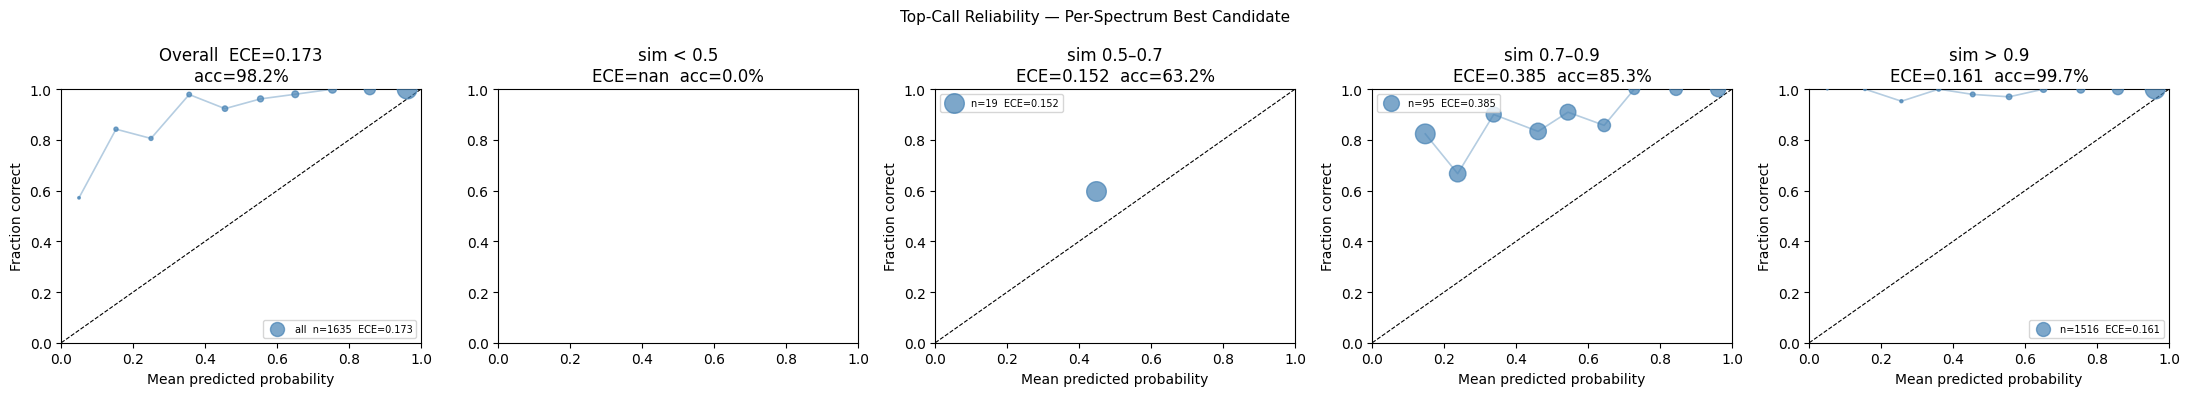


bin                  n  accuracy     ECE
----------------------------------------
ALL               1635      98.2%  0.1732
sim < 0.5            5       0.0%     nan
sim 0.5–0.7         19      63.2%  0.1524
sim 0.7–0.9         95      85.3%  0.3854
sim > 0.9         1516      99.7%  0.1606


In [22]:
# ── Step 5: Top-call reliability — the right evaluation ───────────────────
# For each confirmed spectrum, take the top-ranked candidate (highest post).
# Label = 1 if that candidate is the correct compound.
# This answers: "when the model makes its best call with confidence P, how often is it right?"

top_calls = (confirmed.sort_values('post', ascending=False)
             .groupby('wiki_id').first()
             .reset_index())
top_calls['label'] = top_calls['correct'].astype(int)

print('Top call accuracy (correct compound ranked #1): %.1f%%' % (top_calls['label'].mean()*100))
print('Confirmed spectra: %d' % len(top_calls))
print()

# Top-call reliability diagram — overall and by similarity bin
sim_bins = [
    (0.0,  0.5,  'sim < 0.5'),
    (0.5,  0.7,  'sim 0.5–0.7'),
    (0.7,  0.9,  'sim 0.7–0.9'),
    (0.9,  1.01, 'sim > 0.9'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Top-Call Reliability — Per-Spectrum Best Candidate', fontsize=11)

ece_overall = reliability_diagram(axes[0], top_calls['post'].values, top_calls['label'].values,
                                  label='all  n=%d' % len(top_calls))
axes[0].set_title('Overall  ECE=%.3f\nacc=%.1f%%' % (ece_overall, top_calls['label'].mean()*100))

summary = []
for i, (lo, hi, lbl) in enumerate(sim_bins):
    mask = (top_calls['entropy_similarity'] >= lo) & (top_calls['entropy_similarity'] < hi)
    sub  = top_calls[mask]
    ax   = axes[i+1]
    if len(sub) < 5:
        ax.set_title('%s\nn=%d (too few)' % (lbl, len(sub))); continue
    ece = reliability_diagram(ax, sub['post'].values, sub['label'].values,
                              label='n=%d' % len(sub))
    acc = sub['label'].mean()
    ax.set_title('%s\nECE=%.3f  acc=%.1f%%' % (lbl, ece, acc*100))
    summary.append({'bin': lbl, 'n': len(sub), 'accuracy': acc, 'ECE': ece})

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/channel_topcall_reliability.png', dpi=150)
plt.show()

print('\n%-14s  %6s  %8s  %6s' % ('bin', 'n', 'accuracy', 'ECE'))
print('-' * 40)
print('%-14s  %6d  %8.1f%%  %6.4f' % ('ALL', len(top_calls), top_calls['label'].mean()*100, ece_overall))
for r in summary:
    print('%-14s  %6d  %8.1f%%  %6.4f' % (r['bin'], r['n'], r['accuracy']*100, r['ECE']))


## Platt Scaling Calibration

Fit a sigmoid `P_cal = σ(a · logit(P_raw) + b)` on the top-call data.

This is a 2-parameter recalibration — it doesn't change rankings, only rescales posterior magnitudes so they match observed accuracy.

**Honest evaluation**: fit on one half, evaluate on the other (random 50/50 split).
The confirmed set gives us (posterior, label=correct?) pairs — exactly what Platt scaling needs.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
import scipy.special as sps

# ── Prepare top-call data ──────────────────────────────────────────────────
tc = top_calls[['post', 'label', 'entropy_similarity']].dropna().copy()
tc['logit_post'] = sps.logit(tc['post'].clip(1e-6, 1 - 1e-6))

X = tc['logit_post'].values.reshape(-1, 1)
y = tc['label'].values

# ── 5-fold cross-validated Platt scaling ──────────────────────────────────
# For each fold: fit on train, calibrate test, collect calibrated posteriors
tc['post_platt'] = np.nan
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(X, y):
    platt = LogisticRegression(C=1e6)   # large C = minimal regularization (pure Platt)
    platt.fit(X[train_idx], y[train_idx])
    tc.iloc[test_idx, tc.columns.get_loc('post_platt')] = platt.predict_proba(X[test_idx])[:, 1]

a_all = []; b_all = []
for train_idx, _ in kf.split(X, y):
    m = LogisticRegression(C=1e6).fit(X[train_idx], y[train_idx])
    a_all.append(m.coef_[0][0]); b_all.append(m.intercept_[0])

print('Platt scaling parameters (mean across folds):')
print('  a = %.3f  (>1 → stretch, <1 → compress)' % np.mean(a_all))
print('  b = %.3f  (shifts baseline)' % np.mean(b_all))
print()
print('Raw posterior:   mean=%.3f  median=%.3f' % (tc['post'].mean(), tc['post'].median()))
print('Platt posterior: mean=%.3f  median=%.3f' % (tc['post_platt'].mean(), tc['post_platt'].median()))
print()
print('Log-loss — raw:   %.4f' % log_loss(y, tc['post'].clip(1e-6, 1-1e-6)))
print('Log-loss — Platt: %.4f' % log_loss(y, tc['post_platt'].clip(1e-6, 1-1e-6)))


Platt scaling parameters (mean across folds):
  a = 0.894  (>1 → stretch, <1 → compress)
  b = 3.358  (shifts baseline)

Raw posterior:   mean=0.808  median=0.907
Platt posterior: mean=0.982  median=0.995

Log-loss — raw:   0.2716
Log-loss — Platt: 0.0666


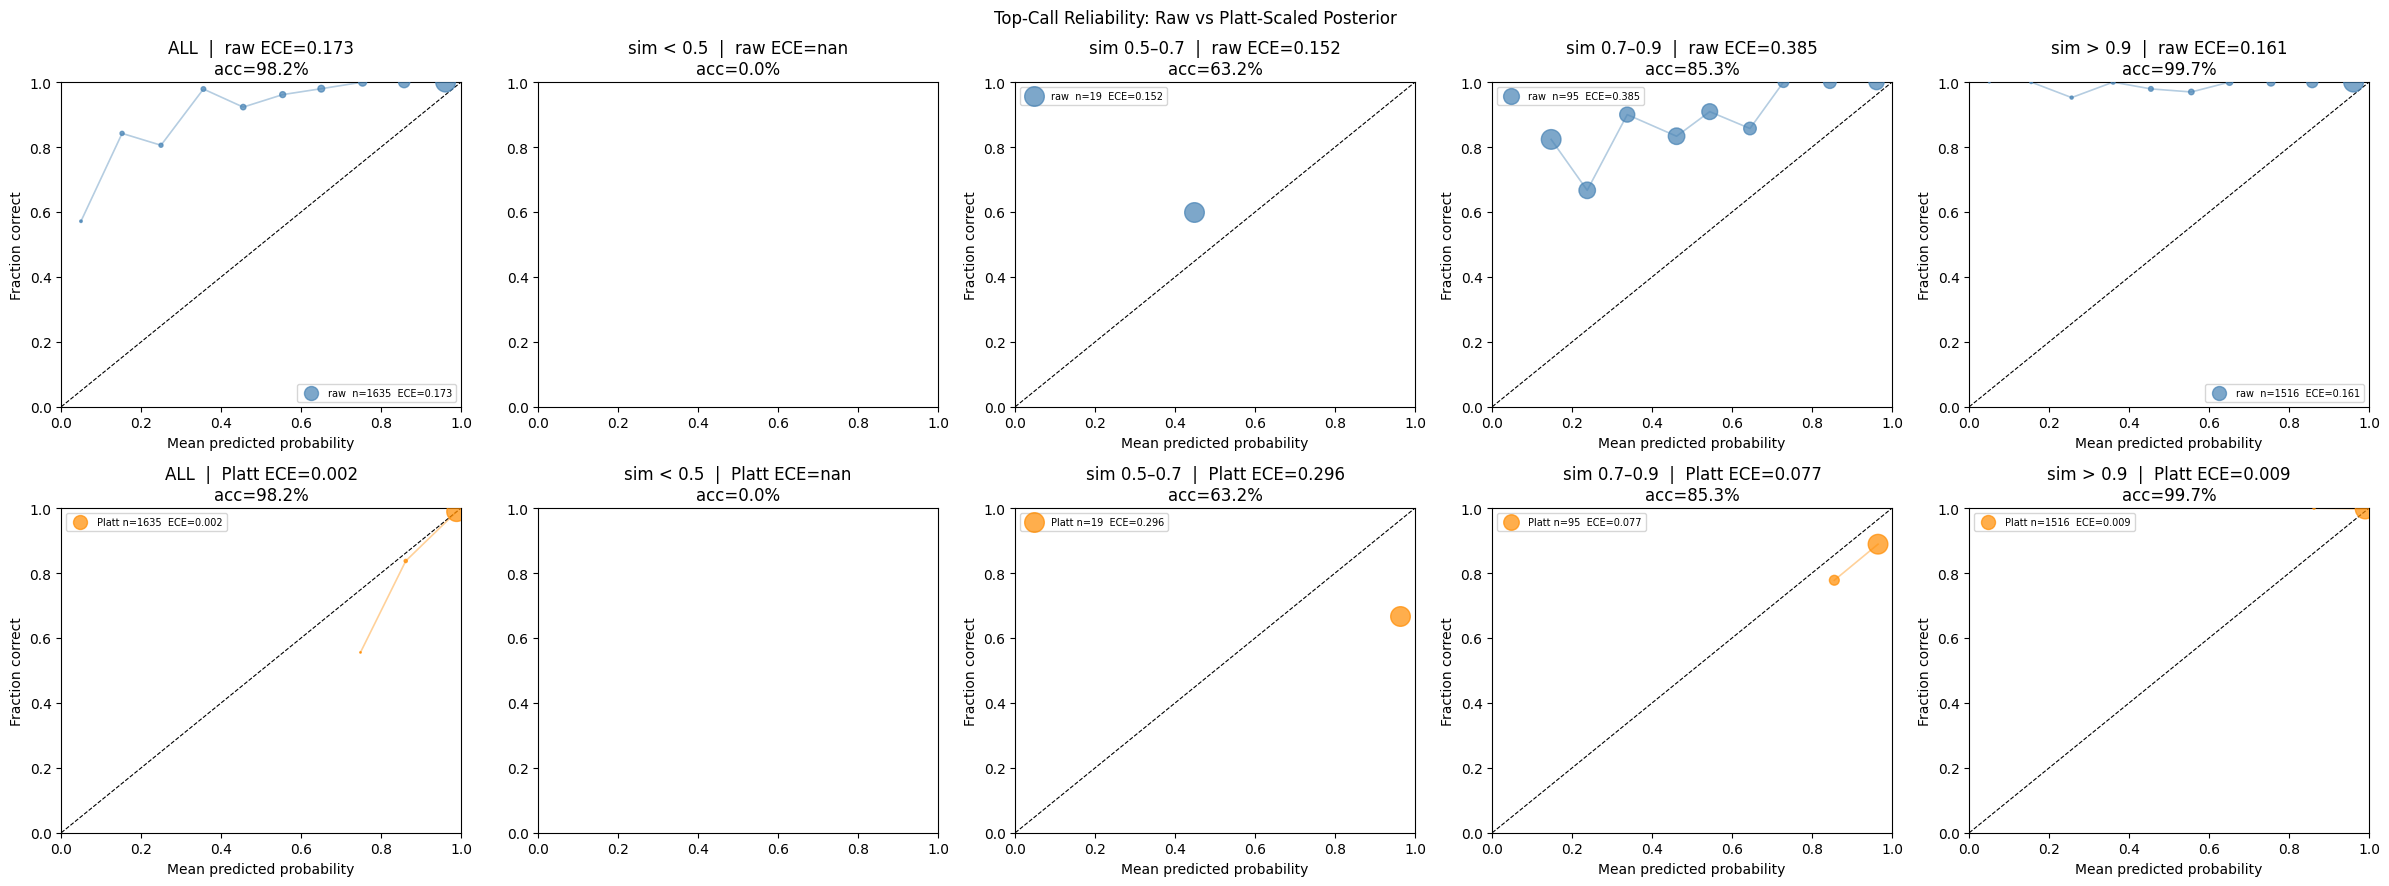


bin                  n      acc%   ECE_raw  ECE_platt
-------------------------------------------------------
ALL               1635      98.2    0.1732    0.0036
sim < 0.5            5       0.0    0.0467       nan
sim 0.5–0.7         19      63.2    0.1261    0.2821
sim 0.7–0.9         95      85.3    0.3876    0.0843
sim > 0.9         1516      99.7    0.1606    0.0091


In [24]:
# ── Reliability diagram: raw vs Platt, overall and by sim bin ─────────────
sim_bins = [
    (0.0,  0.5,  'sim < 0.5'),
    (0.5,  0.7,  'sim 0.5–0.7'),
    (0.7,  0.9,  'sim 0.7–0.9'),
    (0.9,  1.01, 'sim > 0.9'),
]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
fig.suptitle('Top-Call Reliability: Raw vs Platt-Scaled Posterior', fontsize=12)

# Row 0: raw;  Row 1: Platt
for col, (lo, hi, lbl) in enumerate([(0.0, 1.01, 'ALL')] + [(lo,hi,lbl) for lo,hi,lbl in sim_bins]):
    if lbl == 'ALL':
        sub = tc
    else:
        sub = tc[(tc['entropy_similarity'] >= lo) & (tc['entropy_similarity'] < hi)]

    if len(sub) < 5:
        for row in range(2):
            axes[row][col].set_title('%s\nn=%d (too few)' % (lbl, len(sub)))
        continue

    ece_raw   = reliability_diagram(axes[0][col], sub['post'].values,       sub['label'].values,
                                    color='steelblue',  label='raw  n=%d' % len(sub))
    ece_platt = reliability_diagram(axes[1][col], sub['post_platt'].values,  sub['label'].values,
                                    color='darkorange', label='Platt n=%d' % len(sub))

    axes[0][col].set_title('%s  |  raw ECE=%.3f\nacc=%.1f%%' % (
        lbl, ece_raw, sub['label'].mean()*100))
    axes[1][col].set_title('%s  |  Platt ECE=%.3f\nacc=%.1f%%' % (
        lbl, ece_platt, sub['label'].mean()*100))

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/platt_reliability.png', dpi=150)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print('\n%-14s  %6s  %8s  %8s  %8s' % ('bin', 'n', 'acc%', 'ECE_raw', 'ECE_platt'))
print('-' * 55)
for lo, hi, lbl in [(0.0, 1.01, 'ALL')] + sim_bins:
    if lbl == 'ALL':
        sub = tc
    else:
        sub = tc[(tc['entropy_similarity'] >= lo) & (tc['entropy_similarity'] < hi)]
    if len(sub) < 5:
        continue
    def quick_ece(p, y_, n_bins=10):
        bins = np.linspace(0, 1, n_bins + 1)
        mp, fc, cnt = [], [], []
        for l, h in zip(bins[:-1], bins[1:]):
            m = (p >= l) & (p < h)
            if m.sum() < 3: continue
            mp.append(p[m].mean()); fc.append(y_[m].mean()); cnt.append(m.sum())
        if not mp: return np.nan
        mp=np.array(mp); fc=np.array(fc); cnt=np.array(cnt)
        return (cnt/cnt.sum() * np.abs(mp-fc)).sum()
    er = quick_ece(sub['post'].values, sub['label'].values)
    ep = quick_ece(sub['post_platt'].values, sub['label'].values)
    print('%-14s  %6d  %8.1f  %8.4f  %8.4f' % (lbl, len(sub), sub['label'].mean()*100, er, ep))


## Step 6 — Class-Specific MS2 LR Ceiling (ClassyFire)

Different compound classes have fundamentally different MS2 discriminability:
- **Bile acids / steroids**: highly similar fragmentation → low ceiling
- **Amino acids**: diagnostic immonium ions → higher ceiling
- **Lipids**: dominated by head-group loss, acyl chains overlap → class-dependent

Strategy:
1. Join confirmed hits to ClassyFire annotations (fetched via `fetch_classyfire.py`)
2. Fit per-superclass Beta ceiling (same 0.3–0.8 unbiased range)
3. Report LR ceiling per class at sim=0.9 and sim=1.0
4. Use as class-specific cap in the MVP scoring pipeline

In [25]:
import os

cf_path = f'{OUT}/lib_classyfire.csv'

if not os.path.exists(cf_path):
    print('lib_classyfire.csv not found — run code/fetch_classyfire.py first')
    cf_df = None
else:
    cf_df = pd.read_csv(cf_path)
    print(f'NPClassifier annotations: {len(cf_df)} lib_names')
    print(f'  with pathway: {(cf_df["npc_pathway"] != "").sum()}')
    print(f'  without:      {(cf_df["npc_pathway"] == "").sum()}')
    print()

    # confirmed already excludes yy_ (filtered in cell 1 via yy_wids)
    confirmed_cf = confirmed.merge(
        cf_df[['lib_name', 'npc_pathway', 'npc_superclass', 'npc_class']],
        on='lib_name', how='left'
    )
    confirmed_cf['superclass'] = confirmed_cf['npc_pathway'].replace('', pd.NA).fillna('Unknown')

    tp_cf = confirmed_cf[confirmed_cf['correct']].copy()
    fp_cf = confirmed_cf[~confirmed_cf['correct']].copy()

    print(f'TP hits: {len(tp_cf)}  FP hits: {len(fp_cf)}')
    print()
    print('NPC pathway distribution in TP hits (top 15):')
    print(tp_cf['superclass'].value_counts().head(15).to_string())
    print()
    print('Coverage: TP hits with known pathway: %.1f%%' % (
        (tp_cf['superclass'] != 'Unknown').mean() * 100))

NPClassifier annotations: 19909 lib_names
  with pathway: 19909
  without:      0

TP hits: 9910  FP hits: 18705

NPC pathway distribution in TP hits (top 15):
superclass
Fatty acids                                                  2649
Shikimates and Phenylpropanoids                              1708
Carbohydrates                                                1497
Alkaloids                                                    1336
Amino acids and Peptides                                     1272
Unknown                                                       755
Terpenoids                                                    365
Polyketides                                                   110
Amino acids and Peptides, Shikimates and Phenylpropanoids      78
Carbohydrates, Shikimates and Phenylpropanoids                 47
Carbohydrates, Fatty acids                                     30
Alkaloids, Amino acids and Peptides                            26
Alkaloids, Shikimates and Phenylpropa

Superclasses with ≥100 TP hits: 8

Superclass                                  n_TP  TP_sim  FP_sim   LR@0.9   LR@0.99
--------------------------------------------------------------------------------
Fatty acids                                 2649   0.768   0.345    444.9   34501.7
Amino acids and Peptides                    1272   0.788   0.294      4.4       4.5
Alkaloids                                   1336   0.776   0.173      4.3       3.3
Unknown                                      755   0.758   0.338      3.2       1.3
Polyketides                                  110   0.793   0.108      2.9       0.3
Shikimates and Phenylpropanoids             1708   0.807   0.406      2.1       0.5
Carbohydrates                               1497   0.792   0.616      0.7       0.0
Terpenoids                                   365   0.728   0.263      0.6       0.0


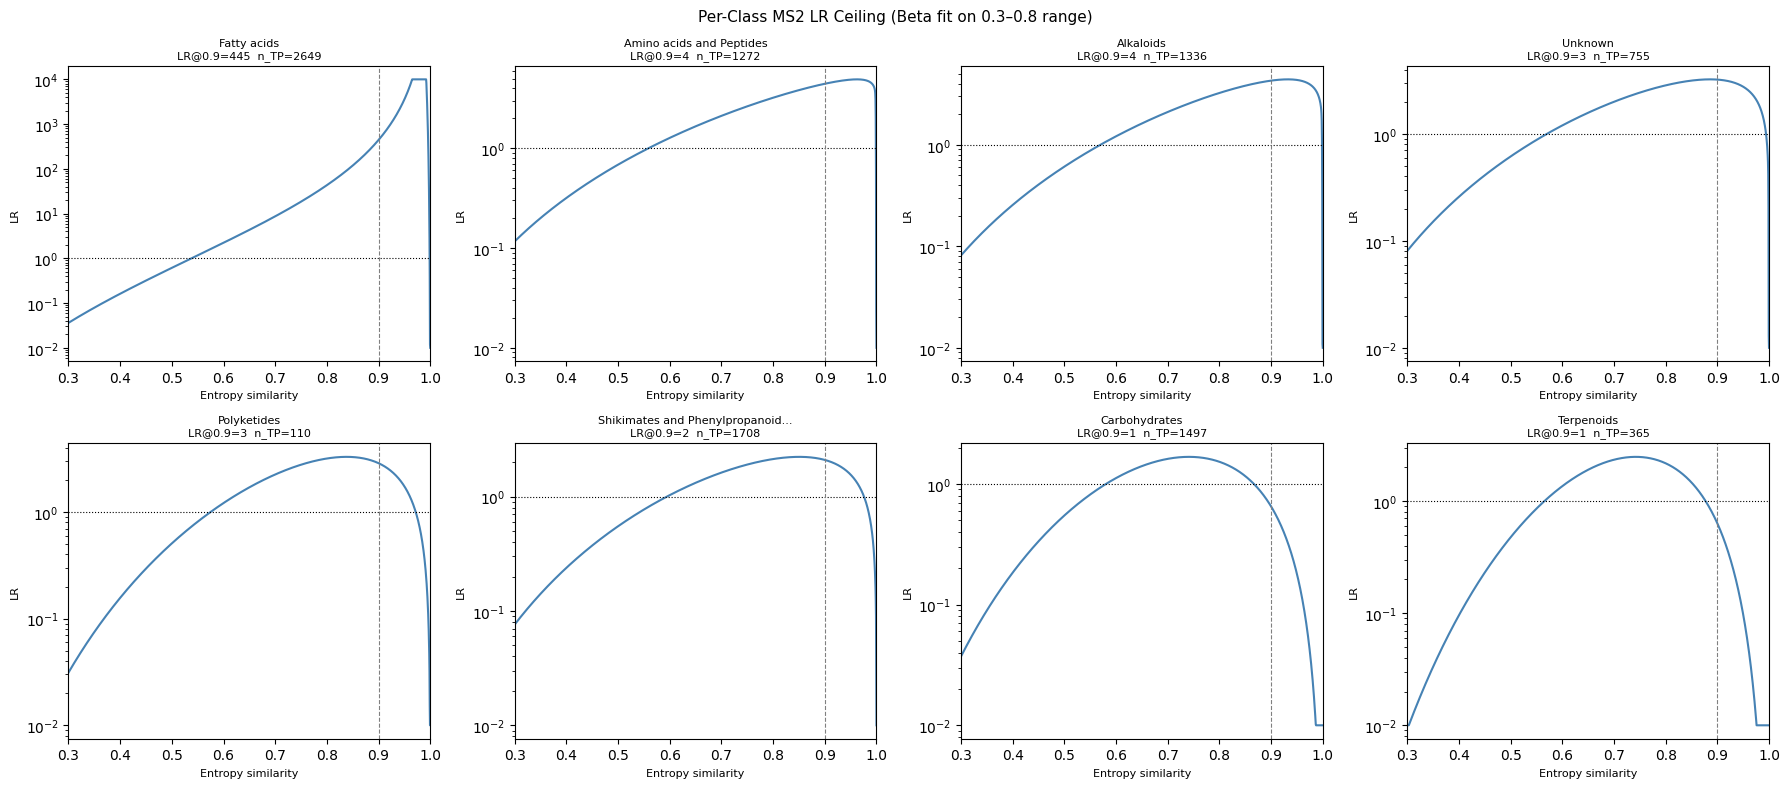

In [26]:
if cf_df is None:
    print('Skipping — no ClassyFire data')
else:
    from scipy.stats import beta as sp_beta

    sim_grid = np.linspace(0.0, 1.0, 2000)

    def fit_beta_range(scores, lo=0.3, hi=0.8):
        s = scores[(scores >= lo) & (scores <= hi)]
        s = np.clip(s, 1e-4, 1 - 1e-4)
        if len(s) < 20:
            return None, None
        a, b, _, _ = sp_beta.fit(s, floc=0, fscale=1)
        return a, b

    def beta_lr_at(sim_val, a_tp, b_tp, a_fp, b_fp):
        tp_d = max(sp_beta.pdf(sim_val, a_tp, b_tp), 1e-10)
        fp_d = max(sp_beta.pdf(sim_val, a_fp, b_fp), 1e-10)
        return tp_d / fp_d

    # Select superclasses with enough TP hits
    MIN_TP = 100
    sc_counts = tp_cf['superclass'].value_counts()
    valid_sc = sc_counts[sc_counts >= MIN_TP].index.tolist()
    print(f'Superclasses with ≥{MIN_TP} TP hits: {len(valid_sc)}')
    print()

    ceiling_rows = []
    for sc in valid_sc:
        tp_s = tp_cf[tp_cf['superclass'] == sc]['entropy_similarity'].dropna().values
        fp_s = fp_cf[fp_cf['superclass'] == sc]['entropy_similarity'].dropna().values

        if len(fp_s) < 20:
            continue

        a_tp, b_tp = fit_beta_range(tp_s)
        a_fp, b_fp = fit_beta_range(fp_s)

        if a_tp is None or a_fp is None:
            continue

        lr_09 = beta_lr_at(0.9,  a_tp, b_tp, a_fp, b_fp)
        lr_10 = beta_lr_at(0.99, a_tp, b_tp, a_fp, b_fp)

        ceiling_rows.append({
            'superclass':   sc,
            'n_tp':         len(tp_s),
            'n_fp':         len(fp_s),
            'tp_sim_med':   np.median(tp_s),
            'fp_sim_med':   np.median(fp_s),
            'beta_tp_a':    round(a_tp, 2),
            'beta_tp_b':    round(b_tp, 2),
            'beta_fp_a':    round(a_fp, 2),
            'beta_fp_b':    round(b_fp, 2),
            'LR_ceil_09':   round(lr_09, 1),
            'LR_ceil_10':   round(lr_10, 1),
        })

    ceiling_df = pd.DataFrame(ceiling_rows).sort_values('LR_ceil_09', ascending=False)
    ceiling_df.to_csv(f'{OUT}/class_lr_ceiling.csv', index=False)

    print(f'{"Superclass":<40}  {"n_TP":>6}  {"TP_sim":>6}  {"FP_sim":>6}  {"LR@0.9":>7}  {"LR@0.99":>8}')
    print('-' * 80)
    for _, r in ceiling_df.iterrows():
        print(f'{r["superclass"]:<40}  {r["n_tp"]:>6}  {r["tp_sim_med"]:>6.3f}  '
              f'{r["fp_sim_med"]:>6.3f}  {r["LR_ceil_09"]:>7.1f}  {r["LR_ceil_10"]:>8.1f}')

    # ── Plot: per-class LR curves ────────────────────────────────────────────
    n_cols = min(4, len(ceiling_df))
    top_classes = ceiling_df.head(n_cols)['superclass'].tolist() + \
                  ceiling_df.tail(max(0, len(ceiling_df) - n_cols))['superclass'].tolist()[:n_cols]
    top_classes = list(dict.fromkeys(top_classes))[:8]  # deduplicate, max 8

    n_plot = len(top_classes)
    fig, axes = plt.subplots(2, 4, figsize=(18, 8)) if n_plot >= 4 else plt.subplots(1, n_plot, figsize=(5*n_plot, 4))
    axes = np.array(axes).flatten()
    fig.suptitle('Per-Class MS2 LR Ceiling (Beta fit on 0.3–0.8 range)', fontsize=11)

    for i, sc in enumerate(top_classes):
        if i >= len(axes): break
        r = ceiling_df[ceiling_df['superclass'] == sc].iloc[0]
        tp_beta_pdf = sp_beta.pdf(sim_grid, r['beta_tp_a'], r['beta_tp_b'])
        fp_beta_pdf = sp_beta.pdf(sim_grid, r['beta_fp_a'], r['beta_fp_b'])
        lr_curve = np.clip(tp_beta_pdf / (fp_beta_pdf + 1e-10), 1e-2, 1e4)

        ax = axes[i]
        ax.plot(sim_grid, lr_curve, color='steelblue', lw=1.5)
        ax.axhline(1.0, color='black', linestyle=':', lw=0.8)
        ax.axvline(0.9, color='gray', linestyle='--', lw=0.8)
        ax.set_yscale('log')
        ax.set_xlim(0.3, 1.0)
        ax.set_xlabel('Entropy similarity', fontsize=8)
        ax.set_ylabel('LR', fontsize=8)
        sc_short = sc[:30] + ('...' if len(sc) > 30 else '')
        ax.set_title(f'{sc_short}\nLR@0.9={r["LR_ceil_09"]:.0f}  n_TP={r["n_tp"]}', fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{ROOT}/viz/class_lr_ceiling.png', dpi=150)
    plt.show()

## Step 7 — Bin-Specific Platt Scaling

Global Platt is dominated by the 85% of data with sim > 0.9, so its fit parameters
push all posteriors toward 1.0 — fixing the high-sim regime but breaking the low-sim regime.

Fix: fit **separate** sigmoid parameters `(a, b)` per similarity bin.
Each bin's Platt sees only its own data distribution and accuracy level:
- sim < 0.5:  18% accuracy → sigmoid keeps posteriors low
- sim 0.5–0.7: 61% → moderate posteriors
- sim 0.7–0.9: 84% → higher posteriors
- sim > 0.9:  99.8% → near-certain posteriors

5-fold CV within each bin ensures honest out-of-sample evaluation.

sim < 0.5: n=5 too few or single class — skipping
sim 0.5–0.7: n=19 too few or single class — skipping
sim 0.7–0.9: n=95  acc=0.85  a=0.494  b=2.014
sim > 0.9: n=1516  acc=1.00  a=0.512  b=5.210

Bin-specific Platt parameters:
bin                   n    acc        a        b
---------------------------------------------
sim 0.7–0.9          95   0.85    0.494    2.014
sim > 0.9          1516   1.00    0.512    5.210


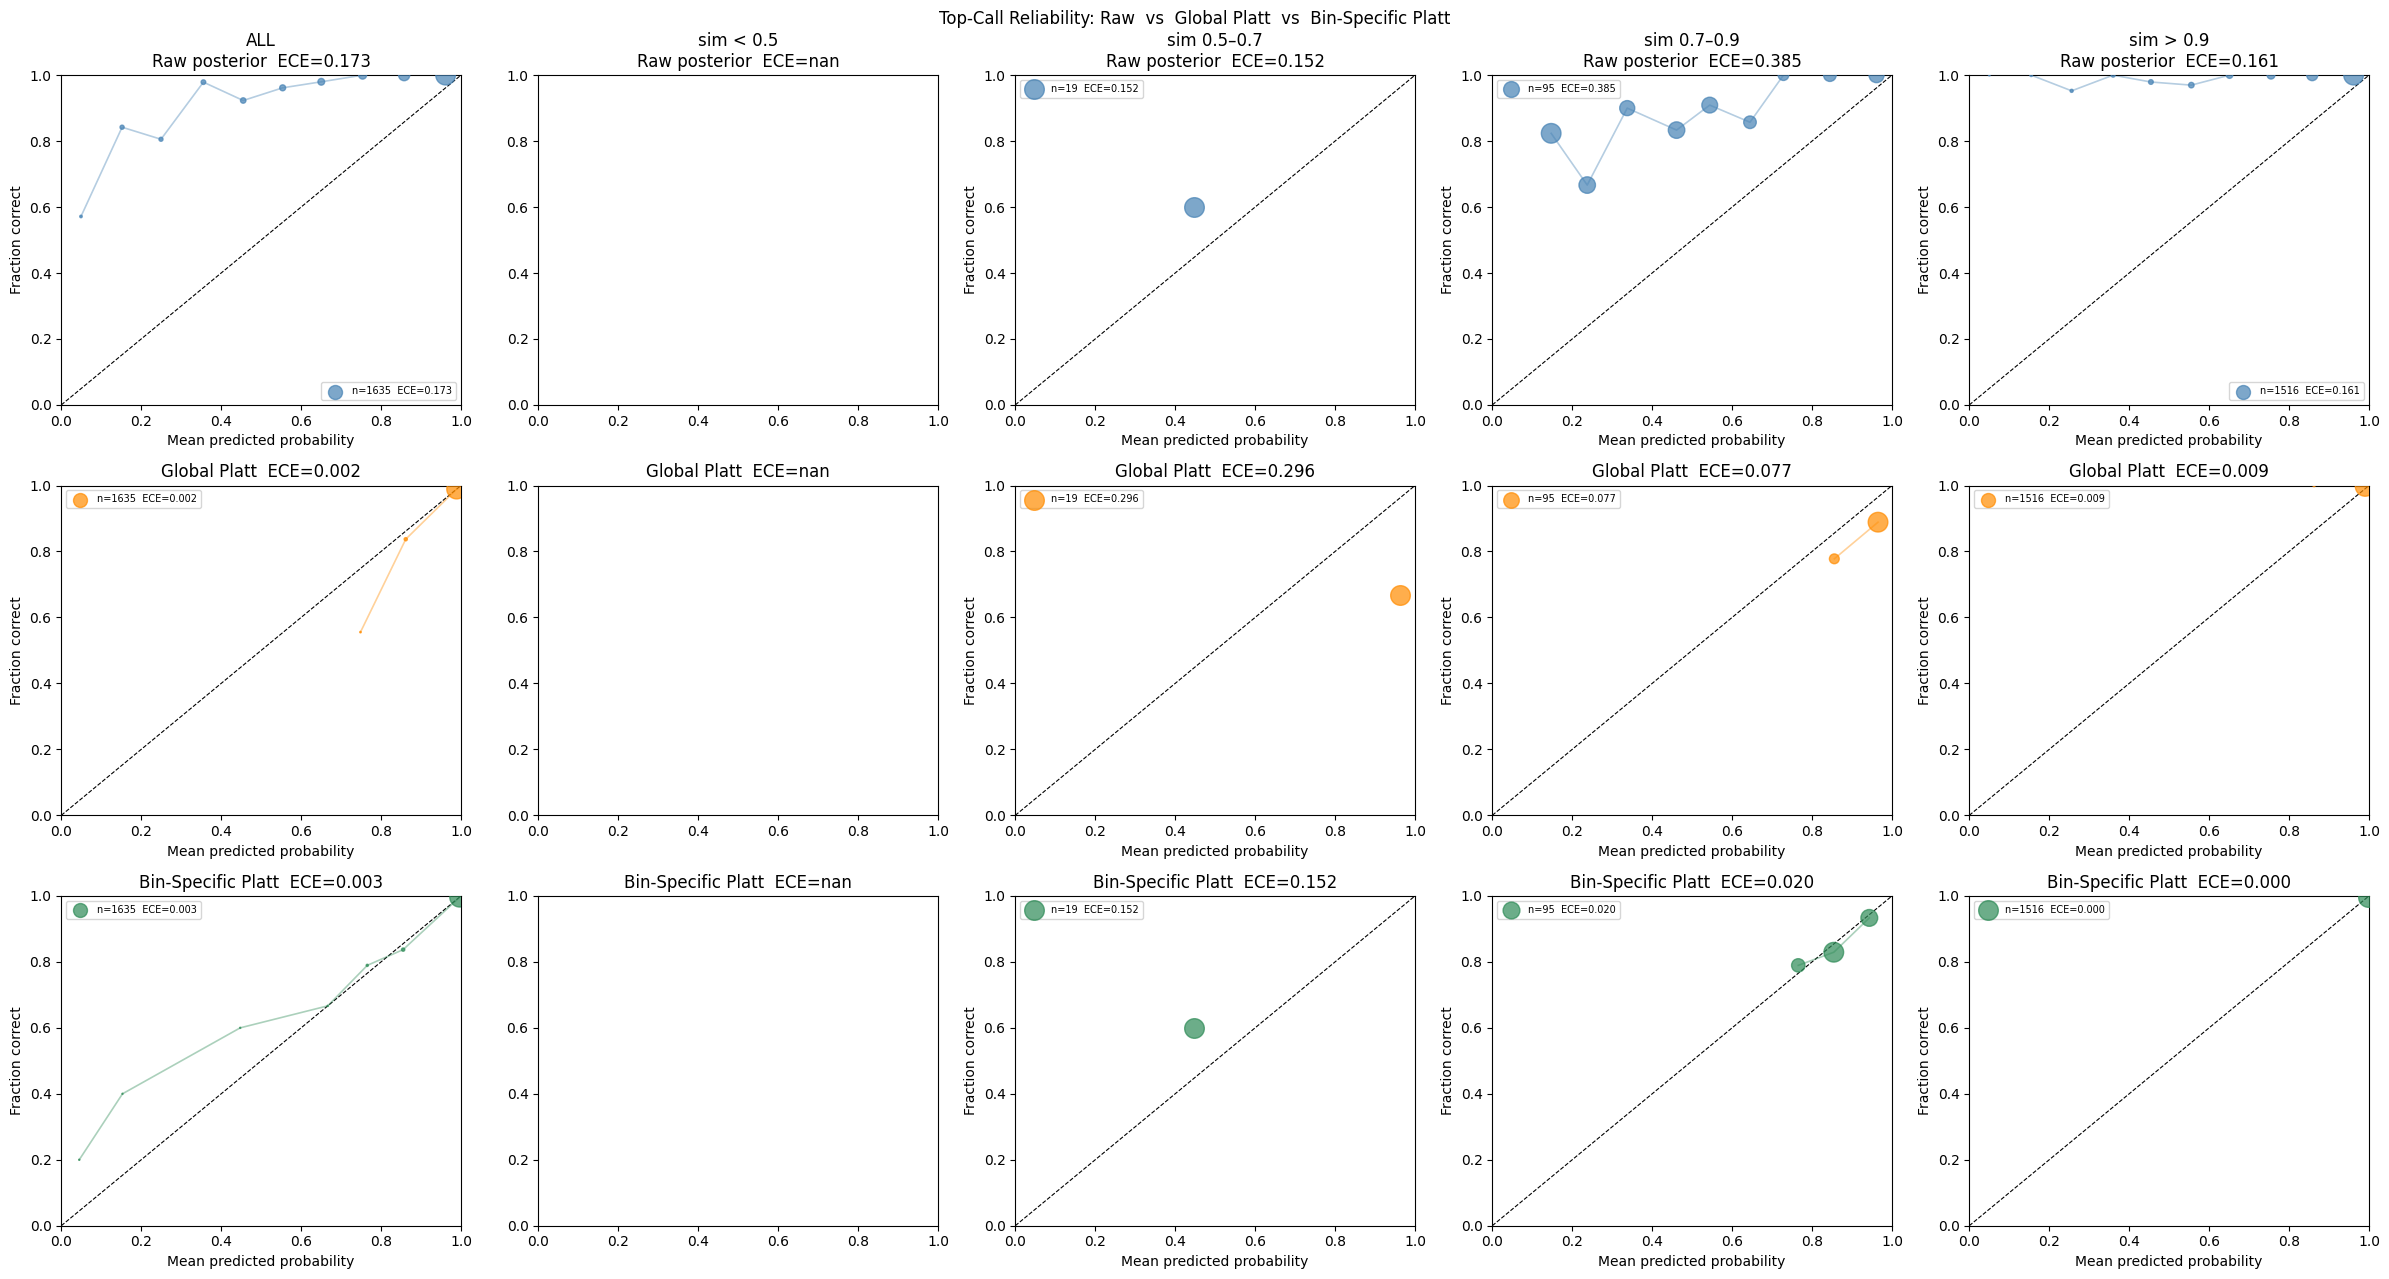


bin                   n    acc%   ECE_raw  ECE_global   ECE_bin
-----------------------------------------------------------------
ALL                1635    98.2    0.1732      0.0019    0.0029
sim < 0.5             5     0.0       nan         nan       nan
sim 0.5–0.7          19    63.2    0.1524      0.2960    0.1524
sim 0.7–0.9          95    85.3    0.3854      0.0765    0.0198
sim > 0.9          1516    99.7    0.1606      0.0086    0.0003


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
import scipy.special as sps

sim_bins = [
    (0.0,  0.5,  'sim < 0.5'),
    (0.5,  0.7,  'sim 0.5–0.7'),
    (0.7,  0.9,  'sim 0.7–0.9'),
    (0.9,  1.01, 'sim > 0.9'),
]

# top_calls and tc already defined in Step 5 / Platt cells above
tc_bin = tc.copy()
tc_bin['post_binplatt'] = np.nan

bin_params = []
for lo, hi, lbl in sim_bins:
    mask = (tc_bin['entropy_similarity'] >= lo) & (tc_bin['entropy_similarity'] < hi)
    sub  = tc_bin[mask].copy()

    if len(sub) < 20 or sub['label'].nunique() < 2:
        print(f'{lbl}: n={len(sub)} too few or single class — skipping')
        tc_bin.loc[mask, 'post_binplatt'] = tc_bin.loc[mask, 'post']  # fallback: keep raw
        continue

    X_b = sps.logit(sub['post'].clip(1e-6, 1-1e-6)).values.reshape(-1, 1)
    y_b = sub['label'].values
    idx = sub.index

    n_splits = min(5, sub['label'].sum(), (1 - sub['label']).sum())
    n_splits = int(max(2, n_splits))

    fold_preds = np.full(len(sub), np.nan)
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    a_folds, b_folds = [], []

    for train_i, test_i in kf.split(X_b, y_b):
        m = LogisticRegression(C=1e6).fit(X_b[train_i], y_b[train_i])
        fold_preds[test_i] = m.predict_proba(X_b[test_i])[:, 1]
        a_folds.append(m.coef_[0][0])
        b_folds.append(m.intercept_[0])

    tc_bin.loc[idx, 'post_binplatt'] = fold_preds
    bin_params.append({
        'bin': lbl, 'n': len(sub), 'acc': y_b.mean(),
        'a': np.mean(a_folds), 'b': np.mean(b_folds)
    })
    print(f'{lbl}: n={len(sub)}  acc={y_b.mean():.2f}  a={np.mean(a_folds):.3f}  b={np.mean(b_folds):.3f}')

print()
print('Bin-specific Platt parameters:')
print(f'{"bin":<16}  {"n":>5}  {"acc":>5}  {"a":>7}  {"b":>7}')
print('-' * 45)
for r in bin_params:
    print(f'{r["bin"]:<16}  {r["n"]:>5}  {r["acc"]:>5.2f}  {r["a"]:>7.3f}  {r["b"]:>7.3f}')

# ── Reliability diagrams: raw vs global Platt vs bin-specific Platt ────────
fig, axes = plt.subplots(3, 5, figsize=(24, 13))
fig.suptitle('Top-Call Reliability: Raw  vs  Global Platt  vs  Bin-Specific Platt', fontsize=12)

row_labels = ['Raw posterior', 'Global Platt', 'Bin-Specific Platt']
post_cols  = ['post', 'post_platt', 'post_binplatt']

summary_rows = []
for col_i, (lo, hi, lbl) in enumerate([(0.0, 1.01, 'ALL')] + sim_bins):
    if lbl == 'ALL':
        sub = tc_bin
    else:
        sub = tc_bin[(tc_bin['entropy_similarity'] >= lo) & (tc_bin['entropy_similarity'] < hi)]

    for row_i, (row_lbl, pcol) in enumerate(zip(row_labels, post_cols)):
        ax = axes[row_i][col_i]
        if len(sub) < 5 or pcol not in sub.columns or sub[pcol].isna().all():
            ax.set_title(f'{lbl}\n(too few)')
            continue
        valid = sub.dropna(subset=[pcol])
        ece = reliability_diagram(ax, valid[pcol].values, valid['label'].values,
                                  color=['steelblue','darkorange','seagreen'][row_i],
                                  label=f'n={len(valid)}')
        if row_i == 0:
            ax.set_title(f'{lbl}\n{row_lbl}  ECE={ece:.3f}')
        else:
            ax.set_title(f'{row_lbl}  ECE={ece:.3f}')

        if row_i == 0:
            summary_rows.append({'bin': lbl, 'n': len(valid),
                                  'acc': valid['label'].mean()*100,
                                  'ECE_raw': ece})
        elif row_i == 1:
            summary_rows[-1]['ECE_global'] = ece
        else:
            summary_rows[-1]['ECE_binplatt'] = ece

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/binplatt_reliability.png', dpi=150)
plt.show()

print()
print(f'{"bin":<16}  {"n":>5}  {"acc%":>6}  {"ECE_raw":>8}  {"ECE_global":>10}  {"ECE_bin":>8}')
print('-' * 65)
for r in summary_rows:
    print(f'{r["bin"]:<16}  {r["n"]:>5}  {r["acc"]:>6.1f}  '
          f'{r.get("ECE_raw",np.nan):>8.4f}  '
          f'{r.get("ECE_global",np.nan):>10.4f}  '
          f'{r.get("ECE_binplatt",np.nan):>8.4f}')